In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import auc, roc_curve, roc_auc_score

In [2]:
data = 'wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv'

!wget $data -O course_lead_scoring_2026.csv

--2026-10-01 16:52:01--  http://wget/
Resolving wget (wget)... failed: No such host is known. .
wget: unable to resolve host address 'wget'
--2026-10-01 16:52:04--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278746 (272K) [text/plain]
Saving to: 'course_lead_scoring_2026.csv'

     0K .......... .......... .......... .......... .......... 18% 1.66M 0s
    50K .......... .......... .......... .......... .......... 36% 3.23M 0s
   100K .......... .......... .......... .......... .......... 55% 15.1M 0s
   150K .......... .......... .......... .......... .......... 73% 6.28M 0s
   200K .......... .......... .......... .......... ...

In [3]:
df = pd.read_csv('course_lead_scoring_2026.csv')
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [4]:
# Check missing values and dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               4852 non-null   object 
 1   industry                  4760 non-null   object 
 2   employment_status         4806 non-null   object 
 3   location                  4792 non-null   object 
 4   annual_income             4631 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                4965 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 351.7+ KB


In [5]:
# Data preparation
# Categorical columns: replace missing values with 'NA'
# Numerical columns: replace missing values with 0

categorical = list(df.dtypes[df.dtypes == 'object'].index)
numerical = list(df.dtypes[df.dtypes != 'object'].index)
numerical.remove('converted')

for c in categorical:
    print(c)
    print(df[c].nunique(), list(df[c].unique()))
    
for col in df.columns:
    if col in categorical and df[col].isnull().any():
        df[col] = df[col].fillna('NA')
    elif col in numerical and df[col].isnull().any():
        df[col] = df[col].fillna(0)
        
df.info()

lead_source
5 ['organic_search', 'social_media', 'referral', 'paid_ads', nan, 'events']
industry
6 ['technology', 'retail', 'manufacturing', 'education', 'healthcare', nan, 'finance']
employment_status
4 ['employed', 'student', nan, 'unemployed', 'self_employed']
location
5 ['europe', 'south_america', nan, 'north_america', 'africa', 'asia']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               5000 non-null   object 
 1   industry                  5000 non-null   object 
 2   employment_status         5000 non-null   object 
 3   location                  5000 non-null   object 
 4   annual_income             5000 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                5000 non-null   float64
 

In [7]:
# Split data into training and holdout validation sets (60/20/20 training/validation/test)

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train['converted'].values
y_val = df_val['converted'].values
y_test = df_test['converted'].values

del df_train['converted']
del df_val['converted']
del df_test['converted']

len(df_train), len(df_val), len(df_test)

(3000, 1000, 1000)

In [10]:
auc(sorted(df_train['lead_score']), y_train)

0.6149999999999999

In [ ]:
# Q1. ROC AUC feature importance

# Using training set:
# For each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth

feature_auc_scores = {}

for n in numerical:
    score = roc_auc_score(y_train, df_train[n])
    if score < 0.5:
        score = roc_auc_score(y_train, -df_train[n])
    feature_auc_scores[n] = score

feature_auc_scores

{'annual_income': 0.6081977776250831,
 'number_of_courses_viewed': 0.7229894623989618,
 'interaction_count': 0.7649203047563227,
 'lead_score': 0.7882254810906102}

As an exploratory comparison, computing the AUC from each numerical feature and the binary target variable (`converted`) gives us a way of seeing each feature's standalone predictive signal. `lead_score` has the highest AUC with the target.

In [16]:
# Q2. Train a logistic regression model using DictVectorizer to one-hot encode

dv = DictVectorizer()
train_dicts = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]

In [18]:
round(roc_auc_score(y_val, y_pred), 3)

0.732

In [27]:
# Q3. Precision, recall, and intersection point
# recall (tpr) = tp / (tp + fn), precision = tp / (tp + fp)
# fpr = fp / (fp + tn)

def confusion_matrix_df(y_true, y_pred):
    scores = []
    thresholds = np.linspace(0, 1, 101) # 0.0 to 1.0 with step 0.01
    
    for t in thresholds:
        actual_pos = y_true == 1
        actual_neg = y_true == 0
        predict_pos = y_pred >= t
        predict_neg = y_pred < t
        tp = (actual_pos & predict_pos).sum()
        tn = (actual_neg & predict_neg).sum()
        fp = (actual_neg & predict_pos).sum()
        fn = (actual_pos & predict_neg).sum()
        
        # CM: TP, FP // FN, TN
        scores.append((t, tp, fp, fn, tn))
    
    columns = ['threshold', 'TP', 'FP', 'FN', 'TN']
    scores_df = pd.DataFrame(scores, columns=columns)
    scores_df['precision'] = scores_df['TP'] / (scores_df['TP'] + scores_df['FP'])
    scores_df['recall'] = scores_df['TP'] / (scores_df['TP'] + scores_df['FN'])
    
    return scores_df

In [28]:
cm_df = confusion_matrix_df(y_val, y_pred)
cm_df[::10]

,threshold,TP,FP,FN,TN,precision,recall
0,0.0,586,414,0,0,0.586000,1.000000
10,0.1,586,414,0,0,0.586000,1.000000
20,0.2,586,414,0,0,0.586000,1.000000
30,0.3,586,403,0,11,0.592518,1.000000
40,0.4,573,362,13,52,0.612834,0.977816
50,0.5,531,294,55,120,0.643636,0.906143
60,0.6,457,190,129,224,0.706337,0.779863
70,0.7,311,82,275,332,0.791349,0.530717
80,0.8,139,23,447,391,0.858025,0.237201
90,0.9,19,1,567,413,0.950000,0.032423


In [34]:
# Find the threshold at which precision and recall curves intersect

cm_df['diff'] = abs(cm_df['precision'] - cm_df['recall'])
argmin = cm_df['diff'].idxmin()
intersection_t = cm_df.loc[argmin, 'threshold']
intersection_t

np.float64(0.63)

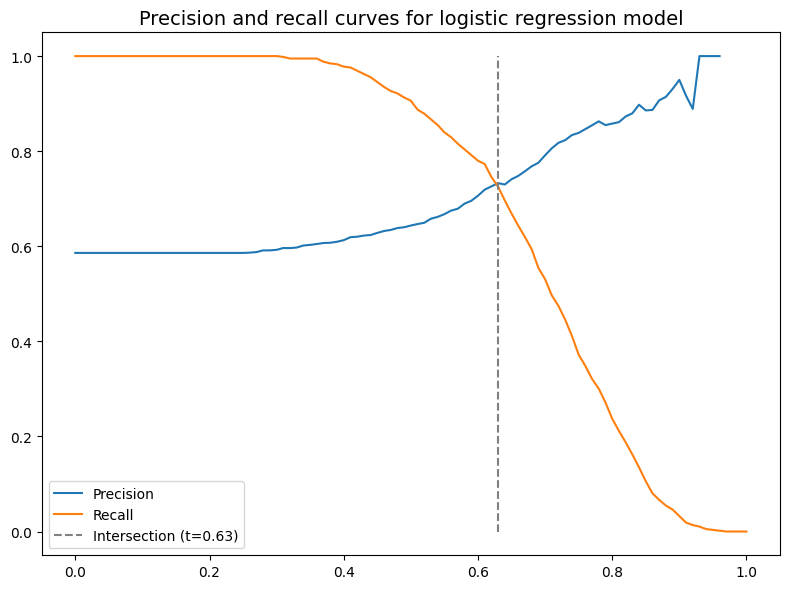

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(cm_df['threshold'], cm_df['precision'], label='Precision')
plt.plot(cm_df['threshold'], cm_df['recall'], label='Recall')
plt.vlines(intersection_t, 0, 1, color='grey', linestyle='--', label=f'Intersection (t={intersection_t:.2f})')
plt.legend()
plt.title('Precision and recall curves for logistic regression model', size=14)
plt.tight_layout();

In [41]:
# Q4. F1 score

cm_df['F1'] = (2 * cm_df['precision'] * cm_df['recall']) / (cm_df['precision'] + cm_df['recall'])
max_f1_t = cm_df.loc[cm_df['F1'].argmax(), 'threshold']
max_f1_t

np.float64(0.41000000000000003)

In [44]:
df_train

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
0,paid_ads,technology,employed,asia,80198.0,5,9,0.91
1,paid_ads,retail,employed,asia,50548.0,2,5,0.48
2,NA,finance,employed,NA,76300.0,0,3,0.42
3,paid_ads,finance,employed,NA,80371.0,2,6,0.49
4,organic_search,finance,employed,asia,73567.0,2,4,0.48
...,...,...,...,...,...,...,...,...
2995,paid_ads,finance,employed,north_america,84573.0,2,3,0.37
2996,events,technology,employed,asia,85051.0,1,3,0.56
2997,events,retail,unemployed,asia,21561.0,0,1,0.17
2998,organic_search,healthcare,unemployed,south_america,31691.0,3,5,0.49


In [ ]:
# Q5. 5-fold CV  with C=1.0

def train(df_train, y_train, C=1.0):
    dv = DictVectorizer()
    dicts = df_train[categorical + numerical].to_dict(orient='records')
    X_train = dv.fit_transform(dicts)
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')
    X_val = dv.transform(dicts)
    y_pred = model.predict_proba(X_val)[:, 1]
    
    return y_pred

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
auc_scores = []
for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]
    
    y_train = df_train['converted'].values
    y_val = df_val['converted'].values
    
    dv, model = train(df_train, y_train, 1.0)
    y_pred = predict(df_val, dv, model)
    
    auc = roc_auc_score(y_val, y_pred)
    auc_scores.append(auc)
     
np.std(auc_scores)

np.float64(0.006853233151022138)

In [46]:
# Q6. Hyperparameter tuning to find best C from [0.000001, 0.001, 1] through 5-fold CV:
# (highest ROC-AUC, lowest stdev)

from tqdm.auto import tqdm

for C in tqdm([0.000001, 0.001, 1]):
    kfold = KFold(n_splits=5, shuffle=True, random_state=1)
 
    auc_scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train['converted'].values
        y_val = df_val['converted'].values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        auc_scores.append(auc)

    print('C=%s: %.3f +- %.3f' % (C, np.mean(auc_scores), np.std(auc_scores)))



  0%|          | 0/3 [00:00<?, ?it/s]

C=1e-06: 0.617 +- 0.019
C=0.001: 0.749 +- 0.010
C=1: 0.732 +- 0.007


C = 0.001 leads to the highest mean ROC-AUC score.